# 02b · What narrowing the channel does, and to which fixation type

*Companion to task 02. No new fits — every panel reads the 175 grid runs and the ten dense
fits from task 01. Regions are pooled wherever they make no difference to the conclusion,
and every plot shows the individual seeds.*

**Three conclusions, each with one figure:**

1. **The cross-region channel is what costs fit, and it costs interactive face most.**
   Squeezing every self block to rank 1 costs at most 0.003 of ceiling-relative $R^2$, the same
   for all three fixation types. Squeezing the cross channel to rank 1 costs interactive face
   0.019 against 0.0145 for the other two, and interactive face is the most expensive at every
   cross rank. (§2)
2. **Interactive face is the hardest fixation type at every rank, including dense.** It is the
   worst-fitted condition in 599 of 600 region-level fits with a constrained channel and in 30
   of 40 in the dense network. The channel bottleneck widens a gap that is already there; the
   within-region bottleneck leaves it alone. (§3)
3. **The constrained network reroutes drive, but rerouted drive does not reproduce the data.**
   With self-recurrence squeezed, the network takes over a region's drive (share 0.68 → 0.97)
   almost for free; with the channel squeezed, self-recurrence takes over (share → 0.18) and
   the fit drops. Interactive face is the fixation type that falls back on self-recurrence
   most. (§5)

| Section | |
|---|---|
| 1 | Definitions, and what the two constraints act on |
| 2 | The main result: fit per fixation type along each marginal |
| 3 | Interactive face is hardest everywhere |
| 4 | Regions, for completeness |
| 5 | Where a region's drive comes from |
| 6 | Flow in time: steady versus bursty |
| 7 | With or against a region's own dynamics |
| 8 | How many dimensions the drive and the state occupy |
| 9 | Reading the result |

## 1. Definitions

Region $r$ has a hidden state $h_r(t)\in\mathbb{R}^{40}$, the activity of its 40 units after the
nonlinearity. The recurrent matrix is sixteen $40\times40$ blocks, $W_{rs}$ mapping region $s$'s
state into region $r$.

| quantity | definition | what it is |
|---|---|---|
| **drive** from $s$ into $r$ | $c_{s\to r}(t) = W_{rs}\,h_s(t)$ | the 40-vector of input region $r$ receives from region $s$ at time $t$. $s=r$ is the region's **self-drive** (its own recurrence). |
| the update | $h_r(t{+}1)=\tanh\!\big(\sum_s c_{s\to r}(t)+b_r\big)$ | the state is the tanh of the total drive plus a bias |
| **drive energy** of a pathway | $\lVert c_{s\to r}(t)\rVert^2$ | squared length of that 40-vector |
| **cross share** | $\dfrac{\sum_{s\neq r}\lVert c_{s\to r}(t)\rVert^2}{\sum_{s}\lVert c_{s\to r}(t)\rVert^2}$ | the fraction of what region $r$ receives that comes from the other three regions rather than from itself. Scale-free, so comparable across cells and fixation types. |
| **state speed** | $\overline{\lVert h_r(t{+}1)-h_r(t)\rVert}$ | how far the state moves per 10 ms bin |
| **state extent** | $\overline{\lVert h_r(t)-\bar h_r\rVert}$ | how far the state sits from its mean |
| **participation ratio** of a trajectory | $(\sum_i\lambda_i)^2/\sum_i\lambda_i^2$ over covariance eigenvalues | the effective number of dimensions it occupies |
| **alignment** | $\cos\big(c_{s\to r}(t),\,c_{r\to r}(t)\big)$ | does the partner push region $r$ the way its own recurrence is already pushing it (positive) or against it (negative) |

**The two constraints.** $r_w$ = rank of each self block $W_{rr}$; $r_c$ = rank of each of the
twelve cross blocks $W_{rs}$. A region's total drive therefore has rank at most $r_w + 3r_c$
— three cross blocks feed each region — which is why the two are not compared at equal rank
but along their **marginals**: one side squeezed, the other left dense.

**What is not comparable.** Raw drive magnitudes differ across cells (a rank-constrained model
compensates with larger weights) and across fixation types (interactive face has half the
target variance). Every cross-cell and cross-condition claim below therefore uses shares,
fractions, cosines and participation ratios.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


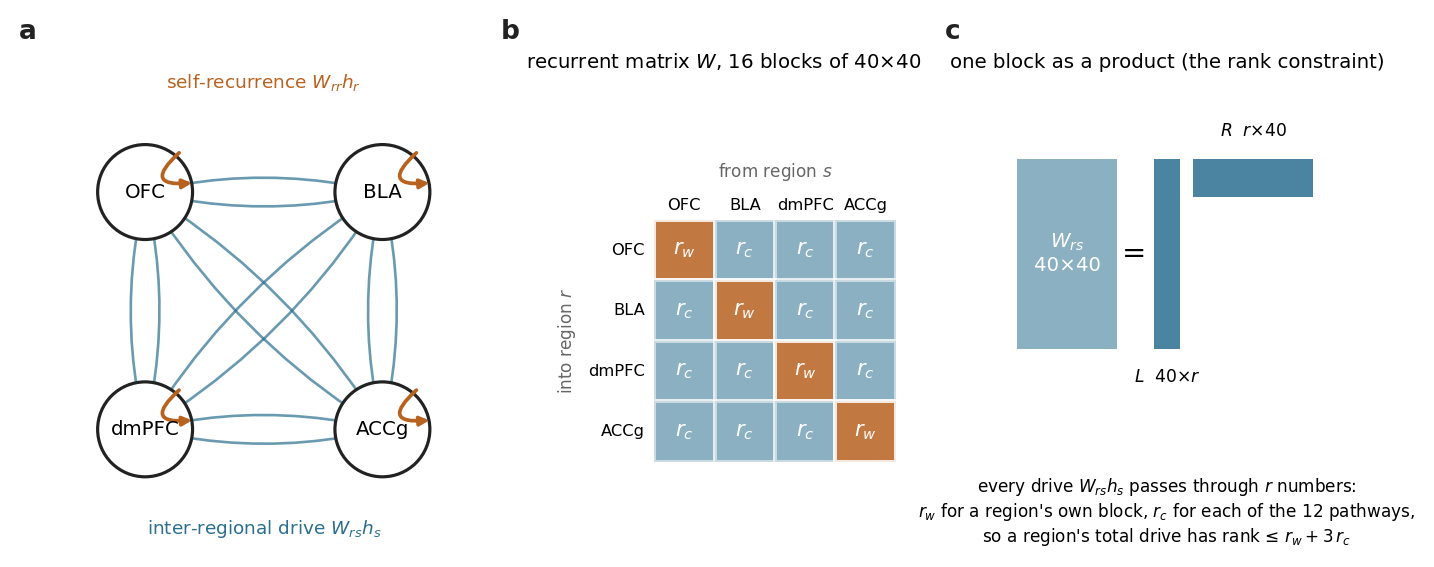

36 cells; reference cells ['full', 'w1_c10', 'w1_c1']


In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
LADDER_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
GRID_ROOT = sweep.resolve_task_root("02_rank_grid", DATASET_CFG_PATH, tree=TREE)
TASK_ROOT = sweep.resolve_task_root("02b_bottleneck_properties", DATASET_CFG_PATH, tree=TREE)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_02b_bottleneck_properties")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

BASE = yaml.safe_load((TASK_ROOT.parent / "base_model.yaml").read_text())
HIDDEN_UNITS = int(BASE["hidden_units"])
RANKS = (1, 2, 3, 5, 10)
ADEQUATE_BAR = 0.98
SELECTED = yaml.safe_load((GRID_ROOT / "selected_bottleneck.yaml").read_text())
REFERENCE_CELLS = ["full", SELECTED["label"], "w1_c1"]

ARMS = {"full": LADDER_ROOT / "full"}
ARMS.update({v.label: GRID_ROOT / v.label
             for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)})
ARMS = {k: p for k, p in ARMS.items() if audit.seed_run_dirs(p)}


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


def with_ranks(frame: pd.DataFrame) -> pd.DataFrame:
    return audit.annotate_rank_grid(frame, hidden_units=HIDDEN_UNITS)


# Fit tables: the grid, and the dense corner from task 01 on the same per-cell ceiling.
fit = with_ranks(pd.read_csv(GRID_ROOT / "tables" / "grid_fit.csv"))
dense_fit = pd.read_csv(LADDER_ROOT / "tables" / "ladder_fit_matched.csv")
dense_fit = dense_fit[dense_fit["label"] == "full"]

show(aviz.plot_bottleneck_schematic(), "fig00_schematic")
print(f"{len(ARMS)} cells; reference cells {REFERENCE_CELLS}")

## 2. The main result

Fit per fixation type along each marginal, **regions pooled** (mean over the four regions per
seed — the region breakdown is in §4 and changes nothing here), **every seed a mark**. Dotted
lines are the dense network. Then the same data as the **cost** relative to dense, which is the
direct reading of "how much does this constraint hurt this fixation type".

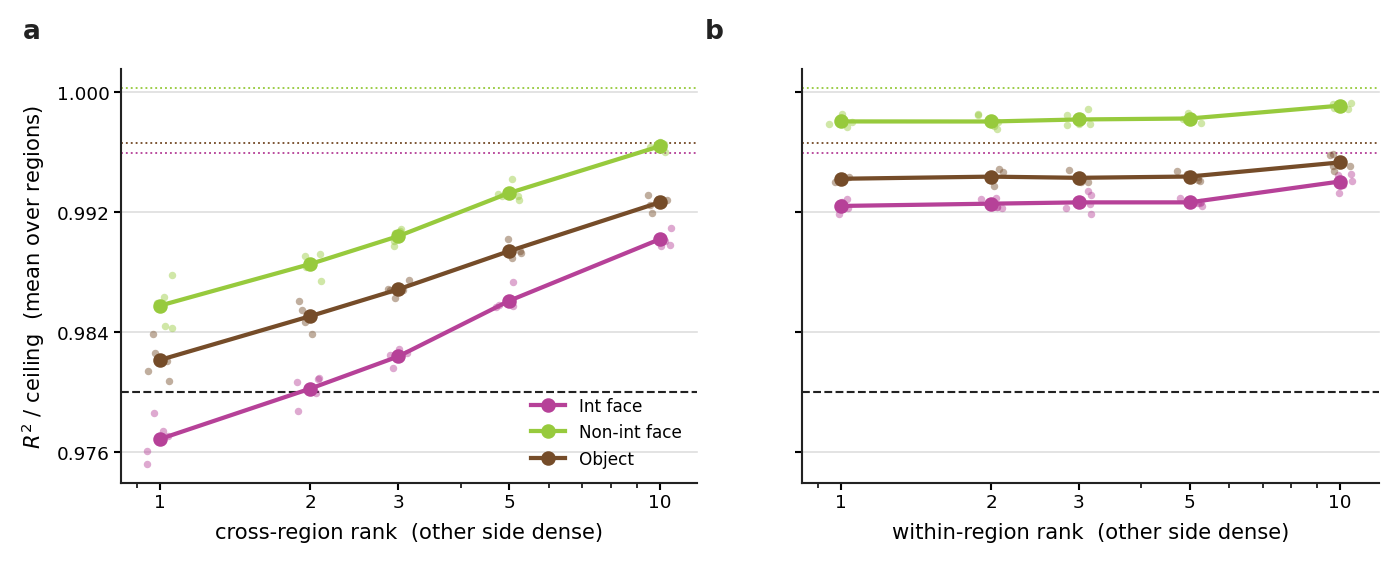

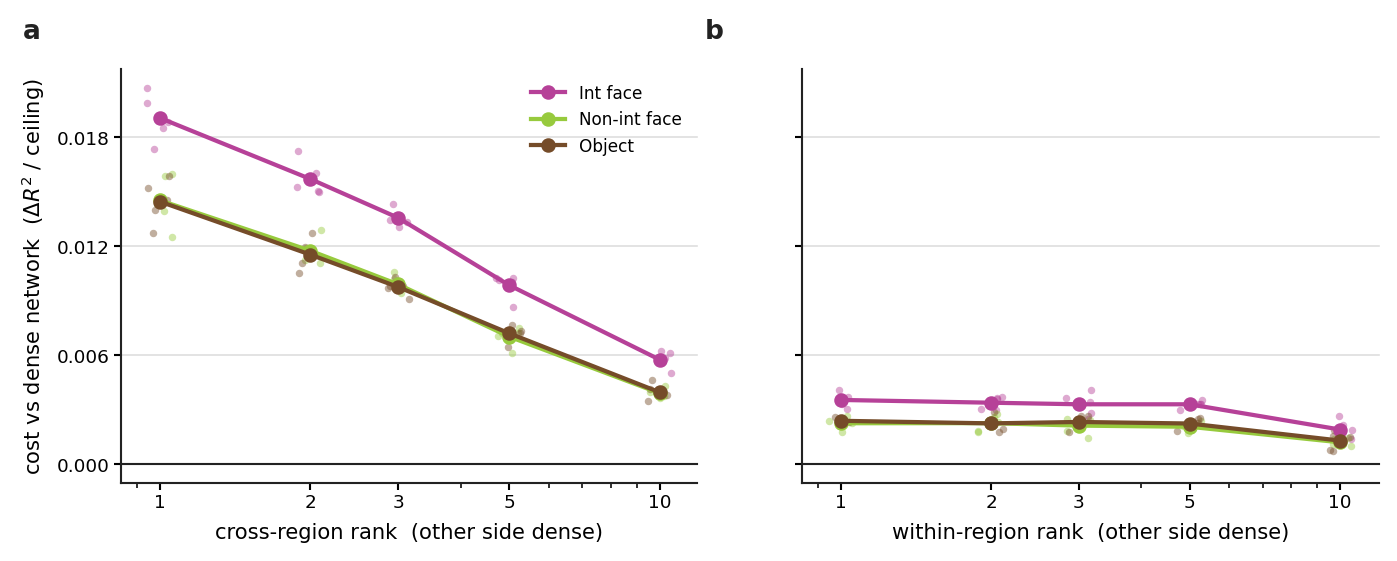

**Cost of the cross-region bottleneck relative to the dense network** (Δ $R^2$/ceiling, mean ± sd over seeds):

mean                                           std  \
condition  face_interactive face_non_interactive  object face_interactive   
rank_cross                                                                  
1                    0.0190               0.0145  0.0144           0.0013   
2                    0.0157               0.0117  0.0115           0.0009   
3                    0.0135               0.0099  0.0097           0.0005   
5                    0.0098               0.0070  0.0072           0.0007   
10                   0.0057               0.0039  0.0040           0.0005   

                                         
condition  face_non_interactive  object  
rank_cross                               
1                        0.0014  0.0012  
2                        0.0007  0.0008  
3                        0.0005  0.0004  
5                        0.0005  0.0005  
10                       0.0003  0.0005

In [2]:
show(aviz.plot_fit_by_condition_pooled(fit, hidden_units=HIDDEN_UNITS, mode="fit", dense=dense_fit, bar=ADEQUATE_BAR),
     "fig01_fit_by_condition")
show(aviz.plot_fit_by_condition_pooled(fit, hidden_units=HIDDEN_UNITS, mode="cost", dense=dense_fit),
     "fig02_cost_by_condition")

per = fit.groupby(["rank_within", "rank_cross", "seed", "condition"])["r2_vs_ceiling"].mean().reset_index()
dense_ref = dense_fit.groupby("condition")["r2_vs_ceiling"].mean()
cross_m = per[per["rank_within"] == HIDDEN_UNITS].copy()
cross_m["cost"] = cross_m["condition"].map(dense_ref) - cross_m["r2_vs_ceiling"]
cost_table = cross_m.groupby(["rank_cross", "condition"])["cost"].agg(["mean", "std"]).unstack("condition")
display(Markdown("**Cost of the cross-region bottleneck relative to the dense network** (Δ $R^2$/ceiling, mean ± sd over seeds):"))
display(cost_table.round(4))

**Conclusion.** The right-hand panels are flat and low: **within-region rank costs 0.002–0.0035
for every fixation type**, the same at rank 1 as at rank 5, with interactive face only ~0.001
above the others. The left-hand panels fall, and the interactive-face line falls furthest: at
cross rank 1 the cost is 0.019 for interactive face against 0.0145 for non-interactive face and
object, and at every rank in between interactive face is the most expensive. The seed spread
(sd ≤ 0.0014) is smaller than the gap between the lines. The channel is what carries
interactive face.

## 3. Interactive face is hardest everywhere

The difference between interactive face and each other fixation type, per seed, along both
marginals. Below zero means interactive face is fitted worse. The dotted line is the same gap
in the dense network — the bottleneck's differential effect is how far the line falls below it.

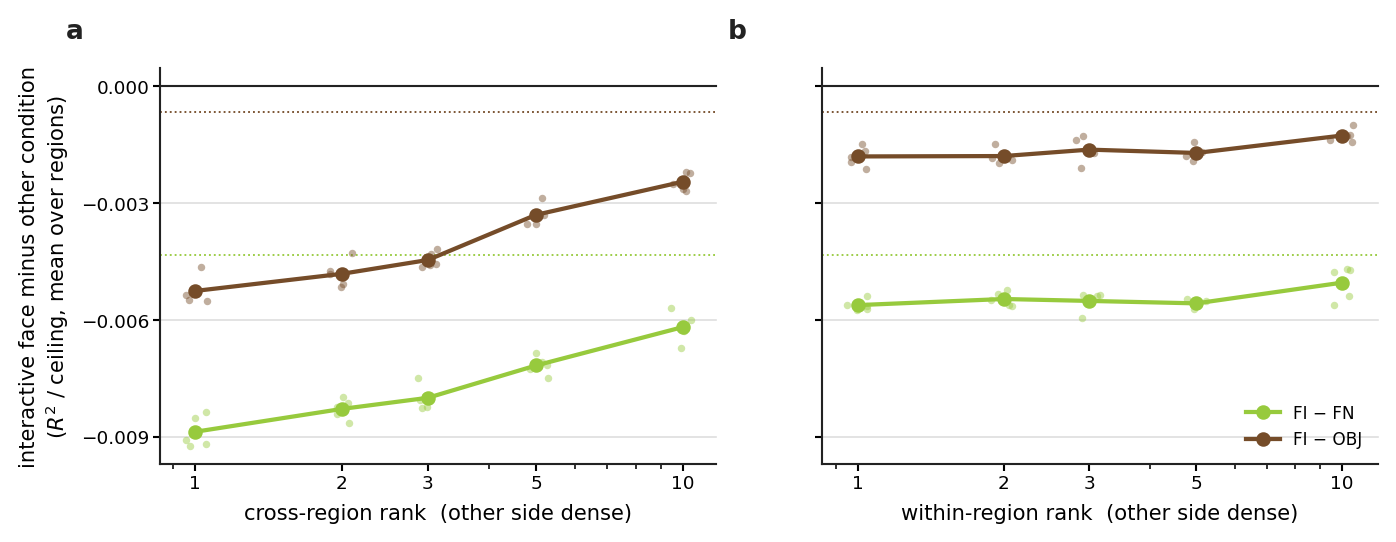

Interactive face is the worst-fitted condition in **599/600** (cell, seed, region) fits with a constrained cross channel, **83/100** with it dense, and **30/40** in the fully dense network.

In [3]:
show(aviz.plot_condition_gap_vs_rank(fit, hidden_units=HIDDEN_UNITS, dense=dense_fit), "fig03_condition_gap")

worst = fit.groupby(["label", "rank_within", "rank_cross", "seed", "region", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
worst_fi = (worst.idxmin(axis=1) == "face_interactive")
dense_worst = dense_fit.groupby(["seed", "region", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
display(Markdown(
    f"Interactive face is the worst-fitted condition in **{int(worst_fi[worst.index.get_level_values('rank_cross') < HIDDEN_UNITS].sum())}"
    f"/{int((worst.index.get_level_values('rank_cross') < HIDDEN_UNITS).sum())}** (cell, seed, region) fits with a constrained cross channel, "
    f"**{int(worst_fi[worst.index.get_level_values('rank_cross') == HIDDEN_UNITS].sum())}"
    f"/{int((worst.index.get_level_values('rank_cross') == HIDDEN_UNITS).sum())}** with it dense, and "
    f"**{int((dense_worst.idxmin(axis=1) == 'face_interactive').sum())}/{len(dense_worst)}** in the fully dense network."))

**Conclusion.** The gap is negative everywhere — interactive face is the hardest fixation
type in the dense network already (dotted lines: −0.004 against non-interactive face, −0.001
against object). Along the cross marginal it opens as the channel narrows, to −0.009 and
−0.005 at rank 1, and every seed follows. Along the within marginal it sits ~0.001 below the
dense gap and does not move with rank. So the bottleneck does not create the interactive-face
deficit; it amplifies one the data already imposes, and only the inter-regional channel does
the amplifying.

## 4. Regions, for completeness

Every region × condition cell, both marginals. The heatmaps show what the pooled figures
assumed: the effect is the same in every region. Interactive face is the darkest cell in each
region at each constrained rank.

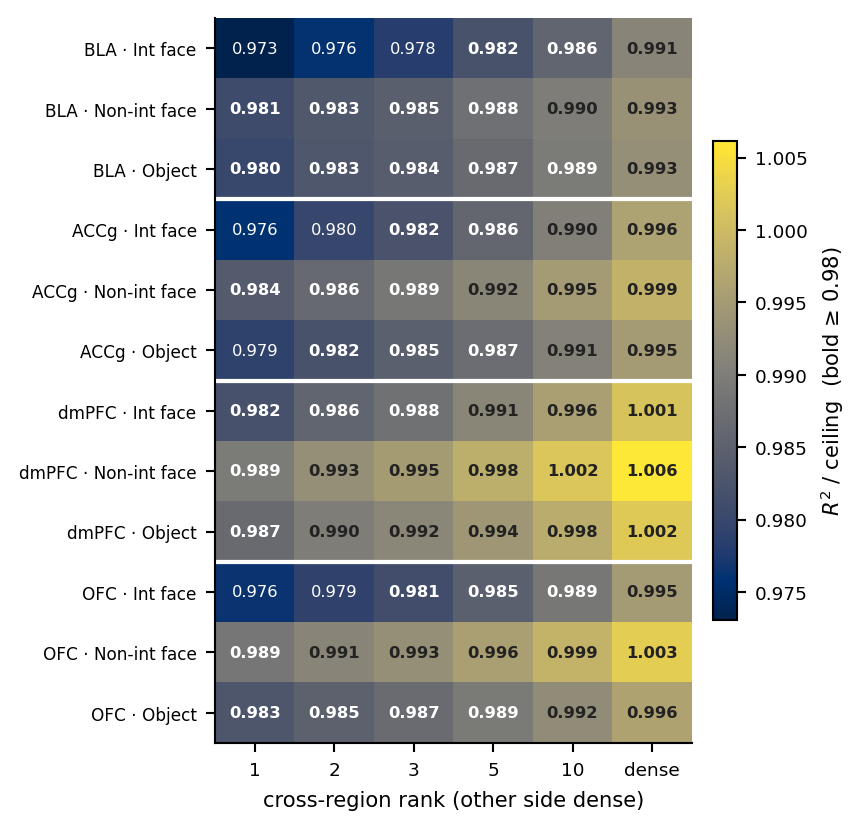

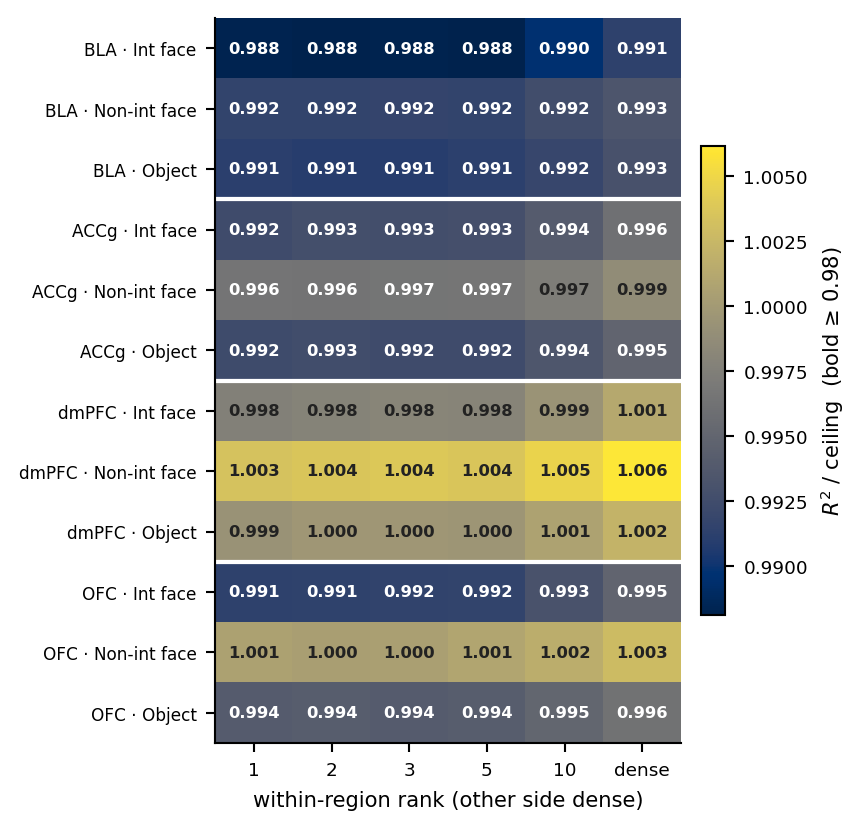

In [4]:
dense_annotated = with_ranks(dense_fit)
for side, other, stem in (("rank_cross", "rank_within", "cross"), ("rank_within", "rank_cross", "within")):
    block = pd.concat([fit[fit[other] == HIDDEN_UNITS], dense_annotated], ignore_index=True)
    block["n_partners"] = block[side]   # reuse the ladder heatmap with rank on the x-axis
    fig = aviz.plot_ladder_cell_heatmap(block, bar=ADEQUATE_BAR)
    ax = fig.axes[0]
    ax.set_xticklabels(["dense" if t.get_text() == str(HIDDEN_UNITS) else t.get_text() for t in ax.get_xticklabels()])
    ax.set_xlabel(f"{stem}-region rank (other side dense)")
    show(fig, f"fig04_{stem}_marginal_cell_heatmap")

## 5. Where a region's drive comes from

The **cross share** — the fraction of a region's drive energy that arrives from the other
three regions — along each marginal, regions pooled, seeds shown.

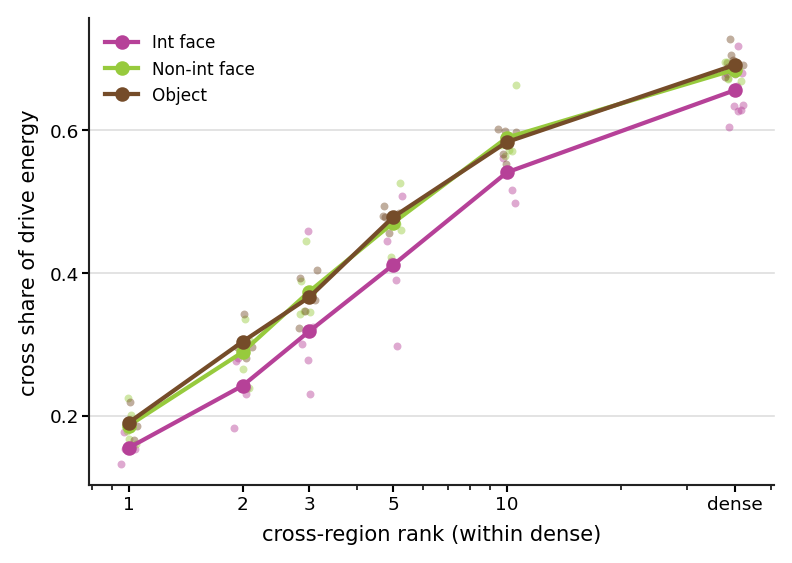

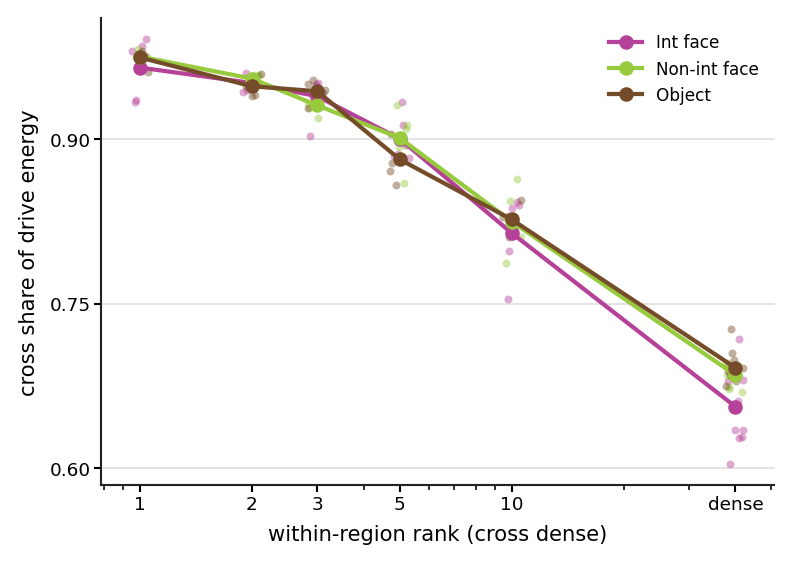

condition,face_interactive,face_non_interactive,object
label,,,
full,0.656,0.685,0.691
w1_c10,0.961,0.951,0.959
w1_c1,0.719,0.728,0.741


In [5]:
props = with_ranks(cached("region_state_properties",
                          lambda: audit.collect_over_arms(ARMS, audit.region_state_properties)))
show(aviz.plot_property_vs_rank_pooled(props[props["rank_within"] == HIDDEN_UNITS], "cross_energy_fraction",
                                       rank_column="rank_cross", hidden_units=HIDDEN_UNITS,
                                       ylabel="cross share of drive energy"), "fig05a_cross_share_vs_cross_rank")
show(aviz.plot_property_vs_rank_pooled(props[props["rank_cross"] == HIDDEN_UNITS], "cross_energy_fraction",
                                       rank_column="rank_within", hidden_units=HIDDEN_UNITS,
                                       ylabel="cross share of drive energy"), "fig05b_cross_share_vs_within_rank")
display(props.groupby(["label", "condition"])["cross_energy_fraction"].mean().unstack().loc[REFERENCE_CELLS].round(3))

**Conclusion.** The network reroutes drive in whichever direction the constraint leaves
open. Squeeze self-recurrence and the network takes over (share 0.68 → 0.97 at within rank 1)
— §2 showed that costs ≤ 0.003. Squeeze the channel and self-recurrence takes over (share →
0.18 at cross rank 1) — §2 showed that costs 0.015–0.019. Self-recurrence substitutes for the
channel in *energy* but not in *content*: it can supply the drive but not reproduce the
trajectories. Interactive face sits lowest at every constrained cross rank (0.155 against
0.19 at rank 1, 0.54 against 0.59 at rank 10) — it is the fixation type that falls back on
self-recurrence most, and the one the narrow channel serves least. The seeds agree on this
ordering; they disagree most (sd ≈ 0.1) where both sides are squeezed.

## 6. Flow in time

The cross share as a time course through the trial, one panel per fixation type, regions
pooled. **Thin lines are individual seeds**; the heavy line is their mean. Three cells: dense,
the selected `w1_c10`, and `w1_c1`, well below the bar.

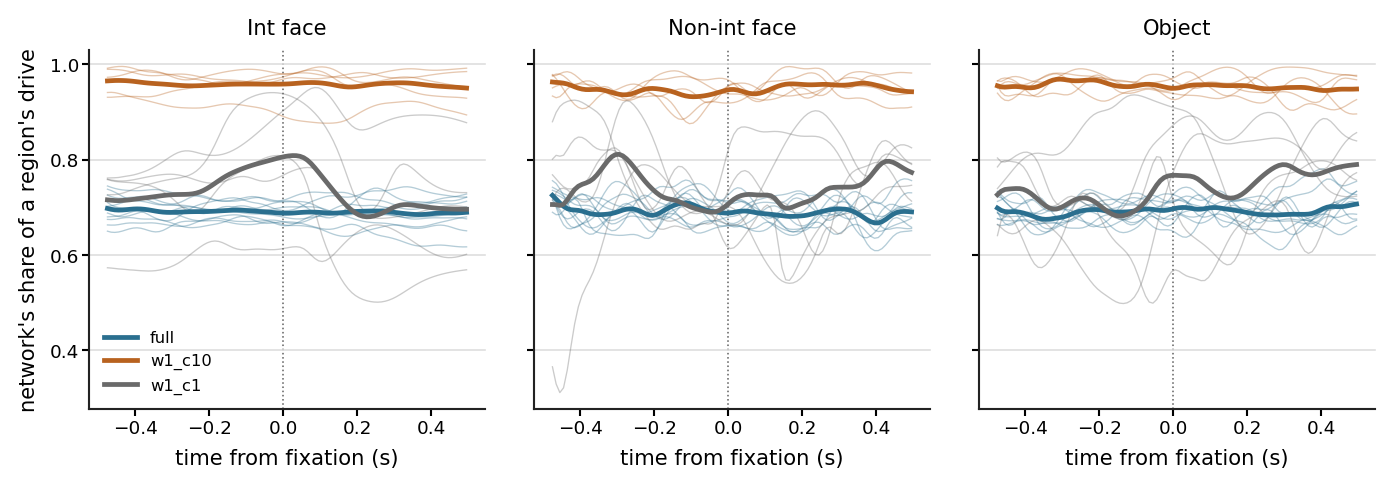

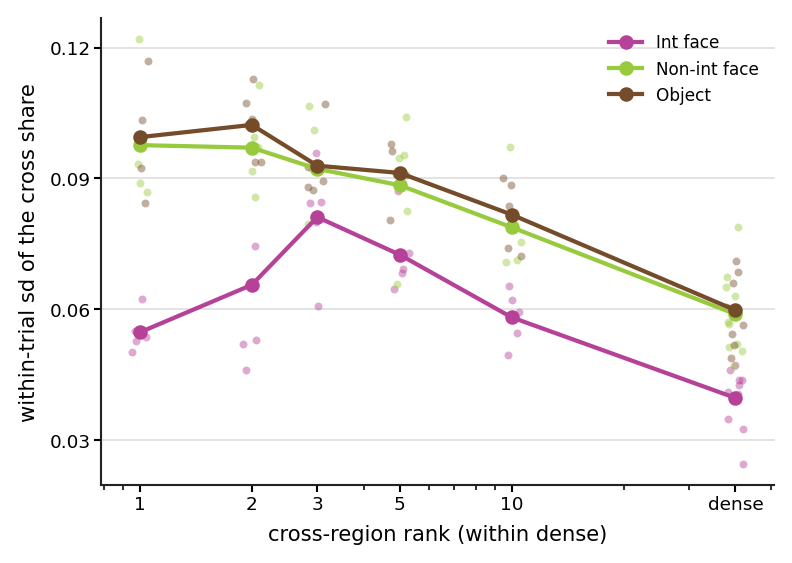

In [6]:
FLOW_CELLS = [c for c in ["full"] + [v.label for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)
                                     if v.arm != "grid" or v.label in REFERENCE_CELLS] if c in ARMS]
flow = cached("time_resolved_flow",
              lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_flow))
decomposed = audit.flow_decomposition(flow)
show(aviz.plot_flow_time_pooled(decomposed, cells=REFERENCE_CELLS), "fig06a_cross_share_time_pooled")

temporal = with_ranks(audit.flow_temporal_summary(decomposed))
show(aviz.plot_property_vs_rank_pooled(temporal[temporal["rank_within"] == HIDDEN_UNITS], "cross_fraction_modulation",
                                       rank_column="rank_cross", hidden_units=HIDDEN_UNITS,
                                       ylabel="within-trial sd of the cross share"), "fig06b_modulation_vs_cross_rank")

**Conclusion.** In the dense network the network's share of a region's drive is steady
through the trial and nearly identical across seeds, and so is it in the selected cell — a
rank-10 channel is wide enough to carry everything at once. Below the bar (`w1_c1`) it is not:
each seed's share swings by 0.2–0.4 within a trial as the region alternates between driving
itself and being driven, and the seeds disagree on *when* — the heavy mean hides swings that
every thin line shows. The within-trial modulation rises as the channel narrows (0.06 → 0.10
for non-interactive face and object); interactive face is steadier at every rank (0.04 → 0.06).

## 7. With or against

Alignment between what a region receives from its partners and what its own recurrence is
already doing, as a mean along the cross marginal and as a time course, regions pooled, seeds
shown.

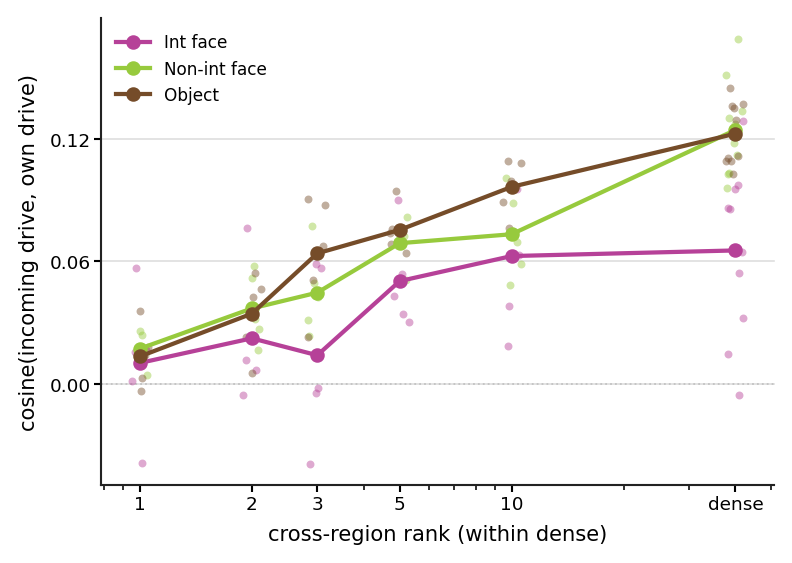

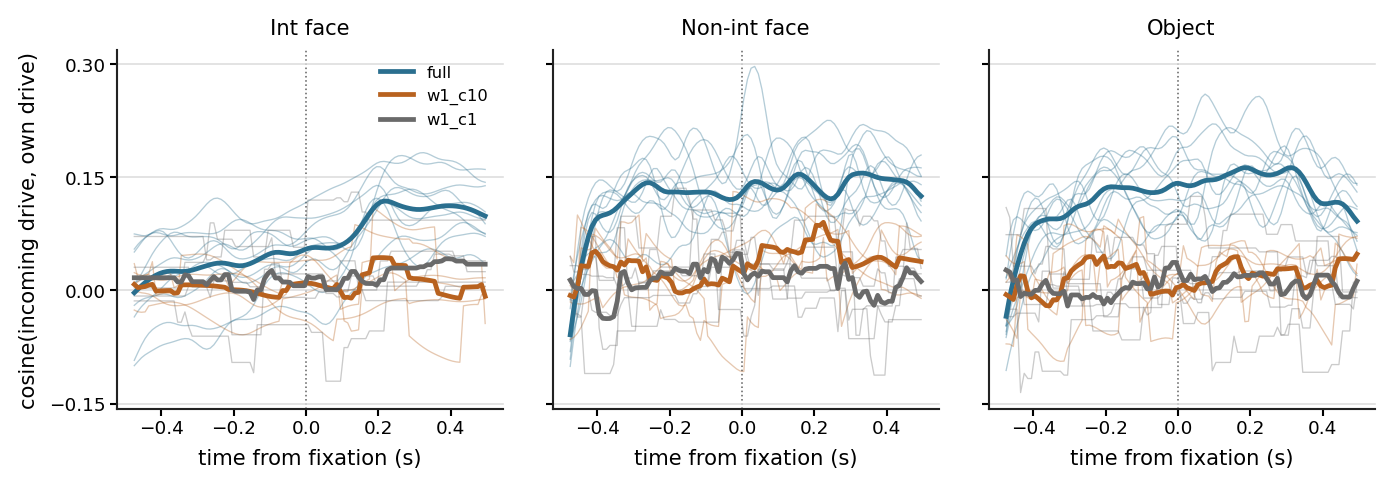

**Is interactive face the least-aligned fixation type?** Dense network: 75% of (seed, region) cells, mean cosine 0.065 against 0.124 / 0.122. `w1_c10`: 50%. `w1_c1`: 30%.

In [7]:
alignment = cached("time_resolved_alignment",
                   lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_alignment))
align_mean = with_ranks(alignment.groupby(["label", "seed", "target", "condition"])["cosine"].mean()
                        .reset_index().rename(columns={"target": "region"}))
show(aviz.plot_property_vs_rank_pooled(align_mean[align_mean["rank_within"] == HIDDEN_UNITS], "cosine",
                                       rank_column="rank_cross", hidden_units=HIDDEN_UNITS, reference=0.0,
                                       ylabel="cosine(incoming drive, own drive)"), "fig07a_alignment_vs_cross_rank")
align_time = (alignment.groupby(["label", "seed", "target", "condition", "time_s"])["cosine"].mean()
              .reset_index())
show(aviz.plot_flow_time_pooled(align_time, cells=REFERENCE_CELLS, value="cosine",
                                ylabel="cosine(incoming drive, own drive)"), "fig07b_alignment_time_pooled")

per_cell = (align_mean.groupby(["label", "seed", "region", "condition"])["cosine"].mean().unstack("condition"))
fi_lowest = (per_cell.idxmin(axis=1) == "face_interactive").groupby(level="label").mean()
dense_means = per_cell.loc["full"].mean()
display(Markdown(
    "**Is interactive face the least-aligned fixation type?** Dense network: "
    f"{fi_lowest['full']:.0%} of (seed, region) cells, mean cosine {dense_means['face_interactive']:.3f} "
    f"against {dense_means['face_non_interactive']:.3f} / {dense_means['object']:.3f}. "
    f"`{SELECTED['label']}`: {fi_lowest[SELECTED['label']]:.0%}. `w1_c1`: {fi_lowest['w1_c1']:.0%}."))

**Conclusion.** In the dense network the partners push mildly *with* a region's own
recurrence (cosine ≈ 0.12 for non-interactive face and object), and about half as much for
interactive face (0.065; the lowest fixation type in three-quarters of seed × region cells —
the audit's I3, at the mean but no longer universal per fit). The time course says where the
difference comes from: for non-interactive face and object the alignment is at ~0.15 from
early in the window and stays there, while for interactive face it sits near 0.03 through the
pre-fixation period and only rises, to ~0.12, about 150 ms after fixation onset. Every dense
seed shows this. Narrowing the channel drives every fixation type's alignment to **zero** at
every time: the constrained network sends directions orthogonal to local recurrence rather
than reinforcing it, and the condition ordering disappears because there is no alignment left
to order.

## 8. Dimensions

Participation ratios of the drive and of the state along the cross marginal. The rank
constraint bounds the drive's rank at $r_w + 3r_c$; the readout needs ~39 dimensions of state.

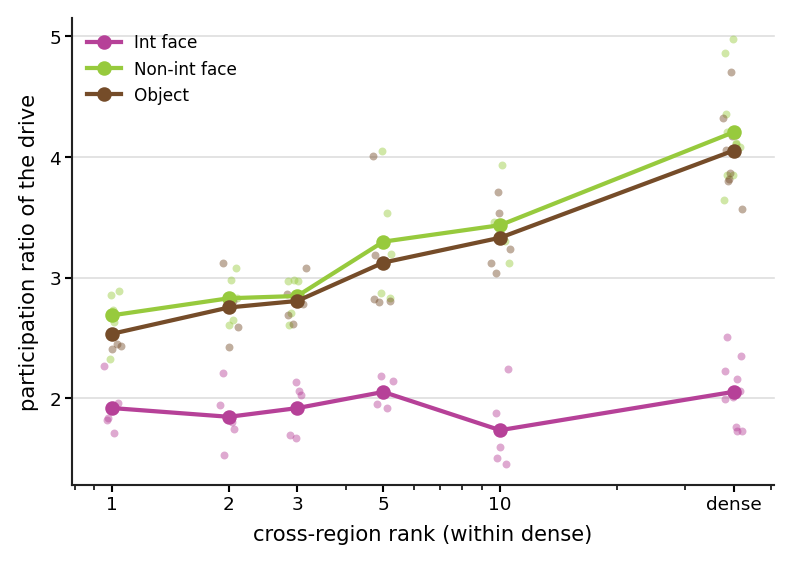

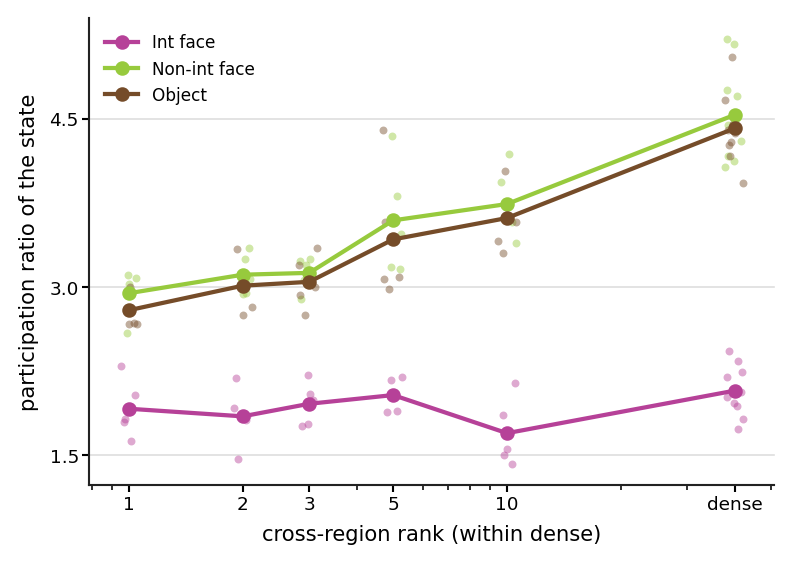

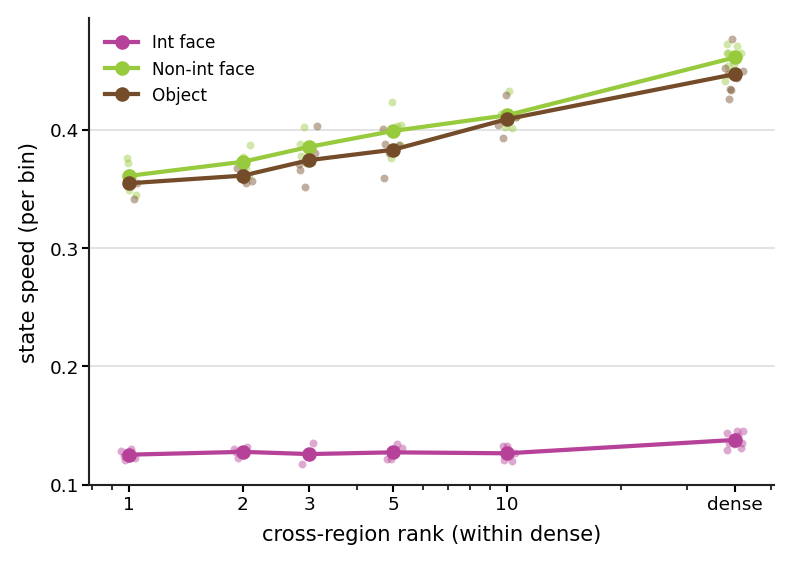

,drive_pr,self_pr,cross_pr,state_pr
label,,,,
full,3.44,3.26,3.55,3.67
w1_c10,2.65,1.00,2.65,2.88
w1_c1,1.75,1.00,1.71,1.94


In [8]:
for prop, label in (("drive_pr", "participation ratio of the drive"), ("state_pr", "participation ratio of the state"),
                    ("state_speed", "state speed (per bin)")):
    show(aviz.plot_property_vs_rank_pooled(props[props["rank_within"] == HIDDEN_UNITS], prop,
                                           rank_column="rank_cross", hidden_units=HIDDEN_UNITS, ylabel=label),
         f"fig08_{prop}_vs_cross_rank")
display(props.groupby("label")[["drive_pr", "self_pr", "cross_pr", "state_pr"]].mean().loc[REFERENCE_CELLS].round(2))

**Conclusion.** Even the dense network's drive and state occupy only 3–4 effective
dimensions; the constraint compresses both further, and the state is re-expanded from the
drive by the nonlinearity by a roughly constant factor. Interactive face's state is smaller
and slower at every rank, which is the target's own compactness (task 07) showing through
rather than an effect of the bottleneck.

## 9. Reading the result

What the bottleneck does, in three sentences:

- **The inter-regional channel is what costs fit, and it costs interactive face most.**
  Within-region rank costs ≤ 0.003 and does not distinguish fixation types. Interactive face is
  already the hardest fixation type in the dense network and the cross-region bottleneck widens
  that gap monotonically.
- **The network reroutes drive freely; only one route reproduces the data.** Squeezing
  self-recurrence hands a region to the network at no cost. Squeezing the channel hands it back
  to self-recurrence, and the fit drops — self-recurrence substitutes in energy, not content.
  Interactive face is the fixation type that falls back on self-recurrence most.
- **A channel wide enough carries everything at once; one too narrow multiplexes.** Below the bar
  the network's share of a region's drive swings within a trial, and the constrained network
  sends directions orthogonal to local recurrence rather than reinforcing it.

**Next:** `03_ensemble.ipynb` refits `w1_c10` ten times and asks what those fits agree on.